# Ensemble
* 앙상블(Ensemble)
    - 여러 개별 모델을 결합하여 하나의 강력한 예측 모델을 구축하는 기법
    - 다른 종류의 모델을 결합하여 앙상블을 구성 (결정트리, 로지스틱 회귀, KNN 등)
    - 주로 분류 문제에서 많이 사용되지만, 회귀 문제에서도 가능함
    - 결국,  Decision Tree Overfitting 방지 <br><br>

* 결합 방법
    - 보팅(Voting) : 서로 다른 알고리즘을 가진 여러 개의 모델을 사용하여 예측을 결합 <br>
                     Hard 보팅 (다수결), Soft 보팅 (예측 확률 평균)
    - 배팅(Bagging) : 동일한 알고리즘을 사용하지만 훈련 데이터셋을 무작위로 부분 샘플링하여 <br>
                여러 개의 부분 모델을 학습, 평균 또는 다수결을 통해 예측 (랜덤 포레스트)
    - 부스팅(Boosting) : 순차적으로 약한 학습기(weak learner)를 학습시켜 <br>
                        강력한 학습기(strong learner)를 만듬. <br>
                        예측 오류에 가중치를 부여하여 반복적으로 모델을 학습 (그래디언트 부스팅, 에이다부스트, XGBoost, CatBoosting)

## Voting
* 서로 다른 알고리즘을 가진 여러 개의 모델을 사용하여 예측
* Hard 보팅 (다수결), Soft 보팅 (예측 확률 평균)
* Soft 보팅 상대적으로 우수 

In [11]:
# 기본 라이브러리 
import numpy as np
import pandas as pd
import seaborn as sns

import matplotlib.pyplot as plt
import matplotlib as mpl            
mpl.rc('font', family='Malgun Gothic')     
plt.rcParams['axes.unicode_minus']=False    

# 데이터 전처리 라이브러리 
from sklearn.model_selection import train_test_split, cross_validate, cross_val_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler

# 사용할 모델 - 분류
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.ensemble import VotingClassifier,  RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import classification_report

# 사이킷런 제공하는 연습 데이터
from sklearn.datasets import load_breast_cancer
from scipy.stats import uniform, randint

# 대화형 HTML이 아니라 정적 다이어그램 형식으로 고정
from sklearn import set_config
set_config(display="diagram")     

import shap

### 데이터 전처리

In [13]:
dye=pd.read_csv('./Data/염색공정_5000_분류.csv', encoding='cp949')
dye.shape

(5000, 11)

In [16]:
X=dye.iloc[:, :-1]
Y=dye.iloc[:, -1]

In [18]:
X_train, X_test, Y_train, Y_test=train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=42)

scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

### 모델 학습

In [21]:
# 개별 모델 정의
knn=KNeighborsClassifier()
lr=LogisticRegression()
dt=DecisionTreeClassifier(max_depth=5, random_state=42)

# 보팅 분류기 정의 (분류기를 구분하기 위해 사용한 임의의 문자열, 객체)
vc=VotingClassifier(estimators=[('KNN', knn), ('LR', lr), ('DT', dt)], voting='soft')      # 다수결  
# vc=VotingClassifier(estimators=[('KNN', knn), ('LR', lr), ('DT', dt)], voting='hard')    # 확률 평균

vc.fit(X_train_scaled, Y_train)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('KNN', ...), ('LR', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2


In [23]:
print(vc.score(X_train_scaled, Y_train))
print(vc.score(X_test_scaled, Y_test))

0.94575
0.943


In [25]:
Y_test_pred=vc.predict(X_test_scaled)
print(classification_report(Y_test, Y_test_pred))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97       848
           1       0.98      0.64      0.77       152

    accuracy                           0.94      1000
   macro avg       0.96      0.82      0.87      1000
weighted avg       0.95      0.94      0.94      1000



In [27]:
# 개별 모델의 평가 출력
for name, model in vc.named_estimators_.items():
    # print(name, model)
    train_score=model.score(X_train_scaled, Y_train)
    test_score=model.score(X_test_scaled, Y_test)

    print("모델:", name)
    print("학습:", train_score)
    print("일반화:", test_score)
    print()

모델: KNN
학습: 0.9705
일반화: 0.961

모델: LR
학습: 0.858
일반화: 0.852

모델: DT
학습: 0.9165
일반화: 0.925



### 최적화
#### 교차 검증

In [30]:
# 5-fold 교차 검증을 사용하여 모델 평가
scores=cross_validate(vc, X_train_scaled, Y_train, cv=5, return_train_score=True)   

print("학습 5-Fold 교차 검증 점수:", scores['train_score'])
print("학습 교차 검증 평균:", scores['train_score'].mean())
print()

print("일반화 5-Fold 교차 검증 점수:", scores['test_score'])
print("학습 교차 검증 평균:", scores['test_score'].mean())

학습 5-Fold 교차 검증 점수: [0.945     0.9365625 0.9415625 0.9434375 0.941875 ]
학습 교차 검증 평균: 0.9416874999999999

일반화 5-Fold 교차 검증 점수: [0.9175  0.93125 0.9375  0.93625 0.9325 ]
학습 교차 검증 평균: 0.931


In [32]:
# 개별 모델들의 교차 검증 점수 계산 및 출력
for name, model in vc.named_estimators_.items():
    # print(name, model)
    scores=cross_val_score(model, X_train_scaled, Y_train, cv=5)
    
    print("모델:", model)
    print("학습 5-Fold 교차 검증 점수:", scores)
    print("학습 교차 검증 평균:", scores.mean())
    print()

모델: KNeighborsClassifier()
학습 5-Fold 교차 검증 점수: [0.92    0.9325  0.94125 0.94625 0.92125]
학습 교차 검증 평균: 0.93225

모델: LogisticRegression()
학습 5-Fold 교차 검증 점수: [0.85375 0.85625 0.855   0.86125 0.86   ]
학습 교차 검증 평균: 0.85725

모델: DecisionTreeClassifier(max_depth=5, random_state=42)
학습 5-Fold 교차 검증 점수: [0.90375 0.9275  0.9375  0.91375 0.91125]
학습 교차 검증 평균: 0.91875



#### HyperParameterTuning
- GridSearchCV, RandomSearchCV

In [35]:
knn_params={
    # HyperParamete >> KNeighborsClassifier().get_params() 
}          
lr_params={
    # HyperParamete >> LogisticRegression().get_params() 
}  
dt_params={
    # HyperParamete  >> DecisionTreeClassifier.get_params() 
}

# GridSearchCV 또는 RandomSearchCV
knn_gs=GridSearchCV(KNeighborsClassifier(), knn_params, cv=5, n_jobs=-1)   
lr_gs=GridSearchCV(LogisticRegression(), lr_params, cv=5, n_jobs=-1 )
dt_gs=GridSearchCV(DecisionTreeClassifier(), dt_params, cv=5, n_jobs=-1 )

knn_gs.fit(X_train_scaled, Y_train)
lr_gs.fit(X_train_scaled, Y_train)
dt_gs.fit(X_train_scaled, Y_train)

# 최적화 모델
knn_best=knn_gs.best_estimator_
lr_best=lr_gs.best_estimator_
dt_best=dt_gs.best_estimator_

In [37]:
# VotingClassifier 구성
vc=VotingClassifier(estimators=[('KNN', knn_best), ('LR', lr_best), ('DT', dt_best)], voting='soft')
vc.fit(X_train_scaled, Y_train)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('KNN', ...), ('LR', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2


In [39]:
print(vc.score(X_train_scaled, Y_train))
print(vc.score(X_test_scaled, Y_test))

0.994
0.985


### DecisionTree
#### 모델 학습

In [64]:
dt1=DecisionTreeClassifier(max_depth=5)
dt2=DecisionTreeClassifier(max_depth=5)
dt3=DecisionTreeClassifier(max_depth=5)

vc=VotingClassifier(estimators=[('DT1', dt1), ('DT2', dt2), ('DT3', dt3)], voting='hard')   # soft
vc.fit(X_train, Y_train)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('DT1', ...), ('DT2', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'hard'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1


In [66]:
print(vc.score(X_train, Y_train))
print(vc.score(X_test, Y_test))

0.9165
0.925


In [68]:
Y_test_pred=vc.predict(X_test)
print(classification_report(Y_test, Y_test_pred))

              precision    recall  f1-score   support

           0       0.93      0.98      0.96       848
           1       0.87      0.60      0.71       152

    accuracy                           0.93      1000
   macro avg       0.90      0.79      0.83      1000
weighted avg       0.92      0.93      0.92      1000



#### 교차 검증

In [71]:
scores=cross_validate(vc, X_train, Y_train, cv=5, return_train_score=True)   

print("학습 5-Fold 교차 검증 점수:", scores['train_score'])
print("학습 교차 검증 평균:", scores['train_score'].mean())
print()

print("일반화 5-Fold 교차 검증 점수:", scores['test_score'])
print("일반화 교차 검증 평균:", scores['test_score'].mean())

학습 5-Fold 교차 검증 점수: [0.9196875 0.92875   0.92      0.9171875 0.92375  ]
학습 교차 검증 평균: 0.921875

일반화 5-Fold 교차 검증 점수: [0.90375 0.9275  0.9375  0.91375 0.91125]
일반화 교차 검증 평균: 0.91875


#### HypterParameterTuning

In [74]:
# params = {
#     'dt1__max_depth': randint(5, 20),                        # 트리의 최대 깊이
#     'dt1__min_samples_split': randint(2, 100),               # 노드 분할에 필요한 최소 샘플수 
#      dt1__min_samples_leaf': randint(1, 21),                 # 리프 노드에 있어야 할 최소 샘플 수
#     'dt1__min_impurity_decrease': uniform(0.0001, 0.0006),   # 분할 후 불순도 감소

#     'dt2__max_depth': randint(5, 20),
#     'dt2__min_samples_split': randint(2, 100),
#      dt2__min_samples_leaf': randint(1, 21),  
#     'dt2__min_impurity_decrease': uniform(0.0001, 0.0006),

#     'dt3__max_depth': randint(5, 20),
#     'dt3__min_samples_split': randint(2, 100),
#      dt3__min_samples_leaf': randint(1, 21),  
#     'dt3__min_impurity_decrease': uniform(0.0001, 0.0006),
# }

In [76]:
param_values={'max_depth': randint(3, 20),                          # 트리의 최대 깊이
              'min_samples_split': randint(2, 100),                 # 노드 분할에 필요한 최소 샘플수 
              'min_samples_leaf': randint(1, 21),                   # 리프 노드에 있어야 할 최소 샘플 수 
              'min_impurity_decrease' : uniform(0.0001, 0.0006)}    # 분할 후 불순도 감소

dt_rs_list=[]
best_models={}

for i in range(1, 4):
    rs=RandomizedSearchCV(DecisionTreeClassifier(), param_values, n_iter=5, cv=5, n_jobs=-1, random_state=42+i)
    rs.fit(X_train, Y_train)
    dt_rs_list.append(rs)
    
    best_models[f'dt{i}']=rs.best_estimator_       # print(rs.best_estimator_)
    
best_models

{'dt1': DecisionTreeClassifier(max_depth=19,
                        min_impurity_decrease=0.00020327953693481855,
                        min_samples_leaf=3, min_samples_split=32),
 'dt2': DecisionTreeClassifier(max_depth=6,
                        min_impurity_decrease=0.00027782555643873677,
                        min_samples_leaf=4, min_samples_split=73),
 'dt3': DecisionTreeClassifier(max_depth=15,
                        min_impurity_decrease=0.0004709766901404149,
                        min_samples_leaf=5, min_samples_split=32)}

In [78]:
estimators=[(name, model) for name, model in best_models.items()]
estimators

vc=VotingClassifier(estimators=estimators, voting='soft')
vc.fit(X_train, Y_train)

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('dt1', ...), ('dt2', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",19
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",32
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",3


In [80]:
print(vc.score(X_train, Y_train))
print(vc.score(X_test, Y_test))

0.99325
0.988


## RandomForest
* 배깅(Bagging, Bootstrap Aggregating)은 샘플 데이터를 부트스트랩(복원 추출) 방식
* 단일 결정 트리로 데이터 샘플링을 서로 다르게 가져가면서 학습을 수행해 보팅 
* 대표적인 알고리즘은 랜덤 포레스트(Random Forest)

### RandomForestClassifier

#### 데이터 전처리 및 모델 학습

In [151]:
dye=pd.read_csv('./Data/염색공정_5000_분류.csv', encoding='cp949')
X=dye.iloc[:, :-1]
Y=dye.iloc[:, -1]

In [153]:
X_train, X_test, Y_train, Y_test=train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=42)

# default : n_estimators=100, max_features='sqrt'
forest=RandomForestClassifier(n_estimators=50, n_jobs=-1, max_depth=5, random_state=42)   
forest.fit(X_train, Y_train)

print(forest.score(X_train, Y_train))
print(forest.score(X_test, Y_test))

0.9165
0.925


In [65]:
Y_test_pred=forest.predict(X_test)
print(classification_report(Y_test, Y_test_pred))

              precision    recall  f1-score   support

         0.0       0.74      0.55      0.63       320
         1.0       0.86      0.94      0.90       980

    accuracy                           0.84      1300
   macro avg       0.80      0.74      0.76      1300
weighted avg       0.83      0.84      0.83      1300



In [155]:
forest.feature_importances_

array([0.20423213, 0.09315305, 0.18136637, 0.27318793, 0.14467324,
       0.00051696, 0.00104105, 0.01251463, 0.07872018, 0.01059446])

#### 학습 결과 시각화

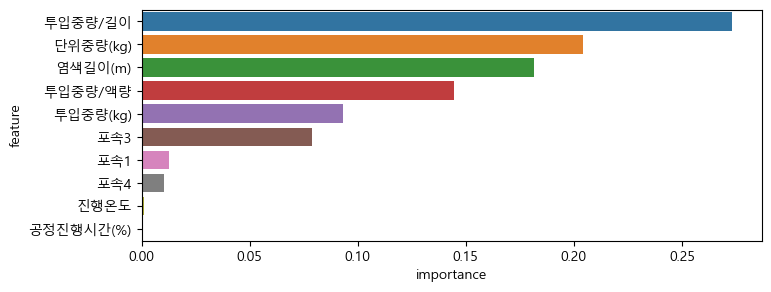

In [159]:
importance_df=pd.DataFrame({'feature': X.columns, 'importance': forest.feature_importances_})
importance_df=importance_df.sort_values(by='importance', ascending=False)
importance_df

plt.figure(figsize=(8, 3))
sns.barplot(data=importance_df, x='importance', y='feature', hue='feature')
plt.show()

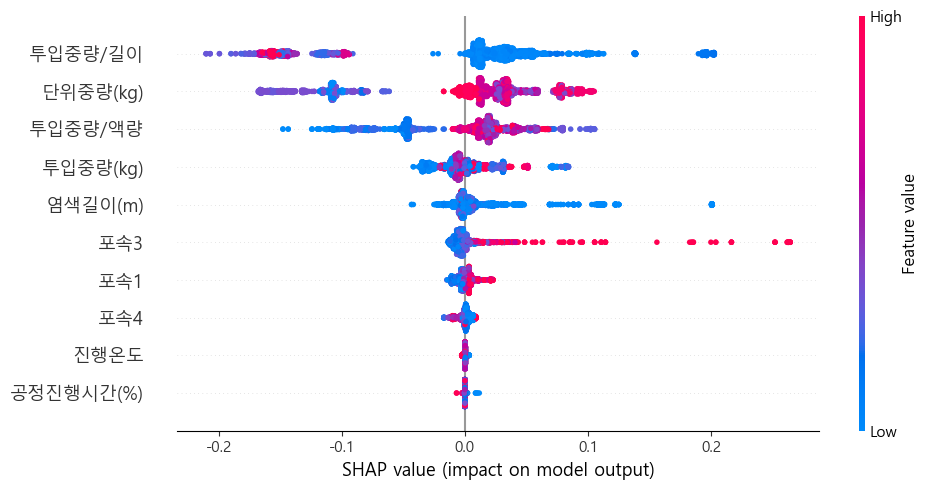

In [179]:
# SHAP(SHapley Additive exPlanations) : 모델이 왜 이런 예측을 했는지 각 변수의 기여도를 설명하는 방법 (불량률 원인)
# TreeExplainer / LinearExplainer / KernelExplainer (KNN 등등) / DeepExplainer

ex=shap.TreeExplainer(forest)
shap_values=ex.shap_values(X_train)
shap_values.shape     # (4000, 10, 2)  데이터 수, 특성 수, 클래스 수
shap.summary_plot(shap_values[:, :, 1], X_train, plot_size=(10, 5))    # 불량 영향 

#### 최적화

In [173]:
# 검증
scores=cross_validate(forest, X_train, Y_train, n_jobs=-1, return_train_score=True)
print(scores['train_score'].mean())
print(scores['test_score'].mean())

0.9125624999999999
0.9109999999999999


In [86]:
# RandomForestClassifier().get_params()

In [59]:
# RandomizedSearchCV
params={'max_depth': randint(5, 20),                        # 트리의 최대 깊이
        'min_samples_split': randint(2, 100),               # 노드 분할에 필요한 최소 샘플수 
        'min_samples_leaf': np.arange(1, 21, 3),            # 리프 노드에 있어야 할 최소 샘플 수 
        'min_impurity_decrease' : uniform(0.0001, 0.001),   # 분할 후 불순도 감소
        'n_estimators': randint(100, 500),                  # 트리 개수
        'max_features': ['sqrt', 'log2', 0.3, None] }       # 특성 수
                                                          
      
rs=RandomizedSearchCV(RandomForestClassifier(random_state=42), params, n_iter=5, n_jobs=-1)   
rs.fit(X_train, Y_train)

print(rs.best_params_)    
print(rs.best_score_)  

{'max_depth': 18, 'max_features': None, 'min_impurity_decrease': 0.0003262975074123288, 'min_samples_leaf': 10, 'min_samples_split': 75, 'n_estimators': 144}
0.9882500000000001


In [61]:
rs_best=rs.best_estimator_
rs_best.score(X_test, Y_test)

0.98

In [63]:
Y_test_pred=rs.predict(X_test)
print(classification_report(Y_test, Y_test_pred))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       848
           1       0.96      0.91      0.93       152

    accuracy                           0.98      1000
   macro avg       0.97      0.95      0.96      1000
weighted avg       0.98      0.98      0.98      1000



### RandomForestRegressor
#### 데이터 전처리

In [90]:
dye=pd.read_csv('./Data/염색공정_5000_회귀.csv', encoding='cp949')
X=dye.iloc[:, :-1]
Y=dye.iloc[:, -1]

#### 모델 학습 및 평가

In [93]:
X_train, X_test, Y_train, Y_test=train_test_split(X, Y, test_size=0.2, random_state=100)

forest=RandomForestRegressor(n_estimators=50, max_depth=5, n_jobs=-1, random_state=100)
forest.fit(X_train, Y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at

In [95]:
print(forest.score(X_train, Y_train))
print(forest.score(X_test, Y_test))

0.8033069572044144
0.7992272676982051


#### 학습 결과 시각화

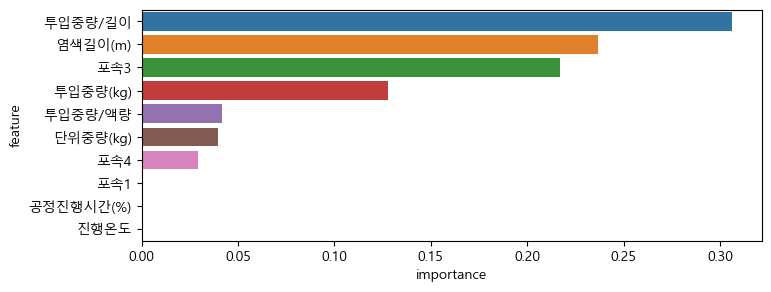

In [98]:
importance_df=pd.DataFrame({'feature': X.columns, 'importance': forest.feature_importances_})
importance_df=importance_df.sort_values(by='importance', ascending=False)
importance_df

plt.figure(figsize=(8, 3))
sns.barplot(data=importance_df, x='importance', y='feature', hue='feature')
plt.show()

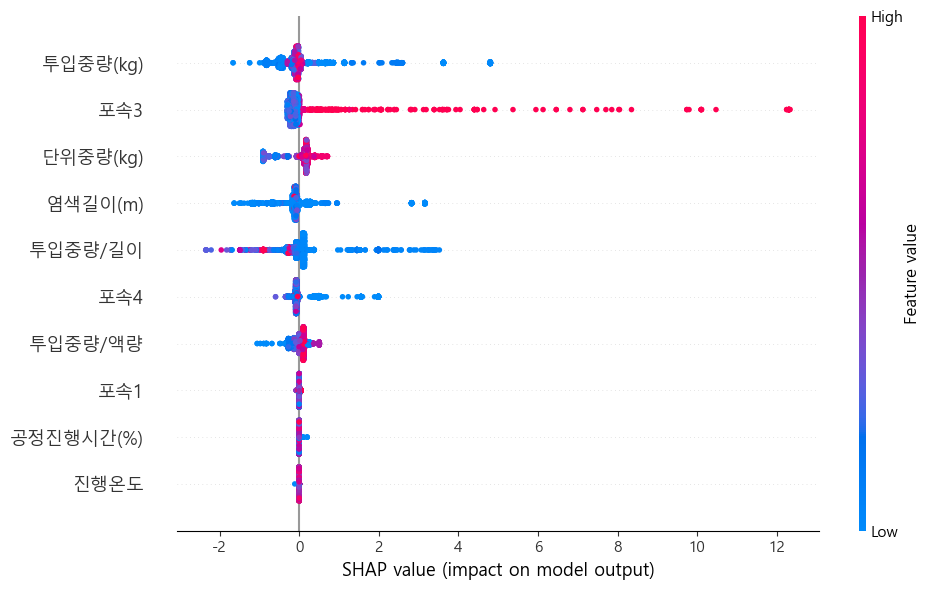

In [99]:
# SHAP(SHapley Additive exPlanations) : 모델이 왜 이런 예측을 했는지 각 변수의 기여도를 설명하는 방법 (불량률 원인)
# TreeExplainer / LinearExplainer / KernelExplainer (KNN 등등) / DeepExplainer

exp=shap.TreeExplainer(forest)
shap_values=exp.shap_values(X_train)
shap.summary_plot(shap_values, X_train, plot_size=(10, 6))

In [184]:
# 최적화
# scores=cross_validate(forest, X_train, Y_train, cv=5, return_train_score=True, n_jobs=-1)
# print(scores['train_score'].mean())
# print(scores['test_score'].mean())

In [182]:
# RandomizedSearchCV
# params={'max_depth': randint(5, 20),                        # 트리의 최대 깊이
#         'min_samples_split': randint(2, 100),               # 노드 분할에 필요한 최소 샘플수 
#         'min_samples_leaf': np.arange(1, 21, 3),            # 리프 노드에 있어야 할 최소 샘플 수 
#         'min_impurity_decrease' : uniform(0.0001, 0.001),   # 분할 후 불순도 감소
#         'n_estimators': randint(100, 500),                  # 트리 개수
#         'max_features': ['sqrt', 'log2', 0.3, None] }       # 특성 수
                                                          
      
# rs=RandomizedSearchCV(RandomForestRegressor(random_state=42), params, n_iter=5, n_jobs=-1, random_state=42)   
# rs.fit(X_train, Y_train)

# print(rs.best_params_)    
# print(rs.best_score_)  

# rs_best=rs.best_estimator_
# rs_best.score(X_test, Y_test)

## Boosting
- 대표 알고리즘 : GBM, XGBoost, LightGBM, CatBoosting
- GradientBoosting
    - 여러 개의 분류기가 순차적으로 학습하면서 앞에 학습한 분류기가 틀린 데이터에 대해서는 가중치를 부여하면서 학습과 예측을 진행
- XGBoosting(Extreme Gradient Boost) : 기존 Gradient Tree Boosting 알고리즘에 과적합 방지를 위해 L1(Lasso), L2(Ridge) 정규화를 지원
- LightGBM : 대규모 데이터에서 처리에서 사용 XGBoosting 구조와 거의 흡사하면, bin 압축 기술이 구가
- CatBoost : 범주형에 특화된 알고리즘, 범주형 전처리 필요 없음 

In [12]:
# !pip install xgboost
# !pip install lightgbm
# !pip install catboost

In [106]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

In [108]:
dye=pd.read_csv('./Data/염색공정_5000_분류.csv', encoding='cp949')
X=dye.iloc[:, :-1]
Y=dye.iloc[:, -1]

In [110]:
X_train, X_test, Y_train, Y_test=train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=42)

In [112]:
# RandomForestClassifier
forest=RandomForestClassifier(n_estimators=50, max_depth=5,  n_jobs=-1, random_state=42)   
forest.fit(X_train, Y_train)

print(forest.score(X_train, Y_train))
print(forest.score(X_test, Y_test))

0.9165
0.925


In [114]:
# GBM : default : n_estimators=100, learning_rate=0.1, max_depth=3
gb=GradientBoostingClassifier(n_estimators=50, max_depth=5, learning_rate=0.2, random_state=42)   
gb.fit(X_train, Y_train)

print(gb.score(X_train, Y_train))
print(gb.score(X_test, Y_test))

1.0
1.0


In [116]:
# XGBossting : L2(기본값 1.0), L1 / 미분1차, 2차 / 병렬계산 
# reg_alpha=1.0 L2, reg_lambda=1.0 
xg=XGBClassifier(n_estimators=50, max_depth=5, learning_rate=0.2, n_jobs=-1, random_state=42)     
xg.fit(X_train, Y_train)

print(xg.score(X_train, Y_train))
print(xg.score(X_test, Y_test))

1.0
1.0


In [40]:
# CatBoossting : 범주형 전처리 필요 없음
cat=CatBoostClassifier(iterations=50, max_depth=5, learning_rate=0.2, verbose=0, random_state=42)
cat.fit(X_train, Y_train)

print(cat.score(X_train, Y_train))
print(cat.score(X_test, Y_test))

1.0
1.0


In [99]:
# End of ---------------------------------------------------------------------